In [1]:
#import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
df= pd.read_csv('telecom_customer_churn.csv') #"c:\Users\SHWETHA\Downloads\archive1\telecom_customer_churn.csv"
df.head()

,Customer ID,Gender,Age,Married,Number of Dependents,City,Zip Code,Latitude,Longitude,Number of Referrals,...,Payment Method,Monthly Charge,Total Charges,Total Refunds,Total Extra Data Charges,Total Long Distance Charges,Total Revenue,Customer Status,Churn Category,Churn Reason
0,0002-ORFBO,Female,37,Yes,0,Frazier Park,93225,34.827662,-118.999073,2,...,Credit Card,65.6,593.30,0.00,0,381.51,974.81,Stayed,NaN,NaN
1,0003-MKNFE,Male,46,No,0,Glendale,91206,34.162515,-118.203869,0,...,Credit Card,-4.0,542.40,38.33,10,96.21,610.28,Stayed,NaN,NaN
2,0004-TLHLJ,Male,50,No,0,Costa Mesa,92627,33.645672,-117.922613,0,...,Bank Withdrawal,73.9,280.85,0.00,0,134.60,415.45,Churned,Competitor,Competitor had better devices
3,0011-IGKFF,Male,78,Yes,0,Martinez,94553,38.014457,-122.115432,1,...,Bank Withdrawal,98.0,1237.85,0.00,0,361.66,1599.51,Churned,Dissatisfaction,Product dissatisfaction
4,0013-EXCHZ,Female,75,Yes,0,Camarillo,93010,34.227846,-119.079903,3,...,Credit Card,83.9,267.40,0.00,0,22.14,289.54,Churned,Dissatisfaction,Network reliability


In [2]:
df.shape

(7043, 38)

In [3]:
df.dtypes

,0
Customer ID,object
Gender,object
Age,int64
Married,object
Number of Dependents,int64
City,object
Zip Code,int64
Latitude,float64
Longitude,float64
Number of Referrals,int64


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 38 columns):
 #   Column                             Non-Null Count  Dtype  
---  ------                             --------------  -----  
 0   Customer ID                        7043 non-null   object 
 1   Gender                             7043 non-null   object 
 2   Age                                7043 non-null   int64  
 3   Married                            7043 non-null   object 
 4   Number of Dependents               7043 non-null   int64  
 5   City                               7043 non-null   object 
 6   Zip Code                           7043 non-null   int64  
 7   Latitude                           7043 non-null   float64
 8   Longitude                          7043 non-null   float64
 9   Number of Referrals                7043 non-null   int64  
 10  Tenure in Months                   7043 non-null   int64  
 11  Offer                              3166 non-null   objec

In [5]:
df.describe()

,Age,Number of Dependents,Zip Code,Latitude,Longitude,Number of Referrals,Tenure in Months,Avg Monthly Long Distance Charges,Avg Monthly GB Download,Monthly Charge,Total Charges,Total Refunds,Total Extra Data Charges,Total Long Distance Charges,Total Revenue
count,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,6361.000000,5517.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000
mean,46.509726,0.468692,93486.070567,36.197455,-119.756684,1.951867,32.386767,25.420517,26.189958,63.596131,2280.381264,1.962182,6.860713,749.099262,3034.379056
std,16.750352,0.962802,1856.767505,2.468929,2.154425,3.001199,24.542061,14.200374,19.586585,31.204743,2266.220462,7.902614,25.104978,846.660055,2865.204542
min,19.000000,0.000000,90001.000000,32.555828,-124.301372,0.000000,1.000000,1.010000,2.000000,-10.000000,18.800000,0.000000,0.000000,0.000000,21.360000
25%,32.000000,0.000000,92101.000000,33.990646,-121.788090,0.000000,9.000000,13.050000,13.000000,30.400000,400.150000,0.000000,0.000000,70.545000,605.610000
50%,46.000000,0.000000,93518.000000,36.205465,-119.595293,0.000000,29.000000,25.690000,21.000000,70.050000,1394.550000,0.000000,0.000000,401.440000,2108.640000
75%,60.000000,0.000000,95329.000000,38.161321,-117.969795,3.000000,55.000000,37.680000,30.000000,89.750000,3786.600000,0.000000,0.000000,1191.100000,4801.145000
max,80.000000,9.000000,96150.000000,41.962127,-114.192901,11.000000,72.000000,49.990000,85.000000,118.750000,8684.800000,49.790000,150.000000,3564.720000,11979.340000


In [6]:
df['Customer Status'].value_counts()

,count
Customer Status,
Stayed,4720
Churned,1869
Joined,454


In [7]:
df['Churn Category'].value_counts()

,count
Churn Category,
Competitor,841
Dissatisfaction,321
Attitude,314
Price,211
Other,182


In [8]:
df['Churn Reason'].value_counts()

,count
Churn Reason,
Competitor had better devices,313
Competitor made better offer,311
Attitude of support person,220
Don't know,130
Competitor offered more data,117
Competitor offered higher download speeds,100
Attitude of service provider,94
Price too high,78
Product dissatisfaction,77


In [9]:
churn_patterns = df.groupby('Churn Category')['Churn Reason'].value_counts()
print(churn_patterns)

Churn Category   Churn Reason                             
Attitude         Attitude of support person                   220
                 Attitude of service provider                  94
Competitor       Competitor had better devices                313
                 Competitor made better offer                 311
                 Competitor offered more data                 117
                 Competitor offered higher download speeds    100
Dissatisfaction  Product dissatisfaction                       77
                 Network reliability                           72
                 Service dissatisfaction                       63
                 Limited range of services                     37
                 Poor expertise of online support              31
                 Lack of self-service on Website               29
                 Poor expertise of phone support               12
Other            Don't know                                   130
                 

In [10]:
import seaborn as sns

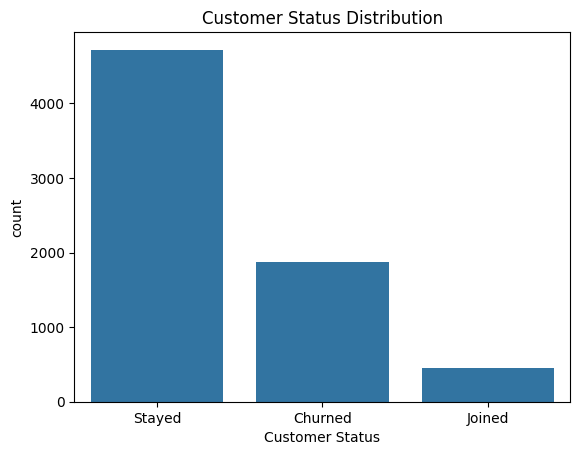

In [11]:
sns.countplot(data=df, x='Customer Status')
plt.title("Customer Status Distribution")
plt.show()

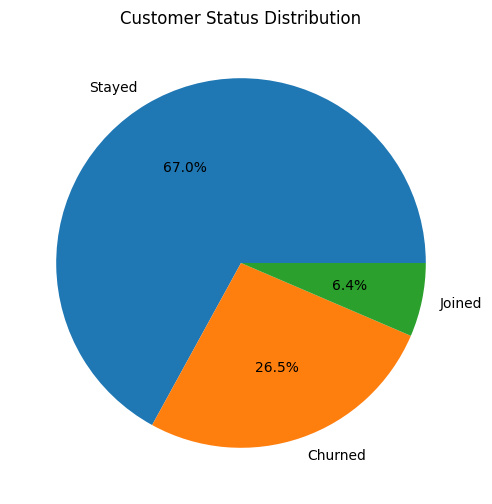

In [12]:
df['Customer Status'].value_counts().plot(kind='pie', autopct='%1.1f%%', figsize=(6, 6))
plt.title("Customer Status Distribution")
plt.ylabel('')
plt.show()

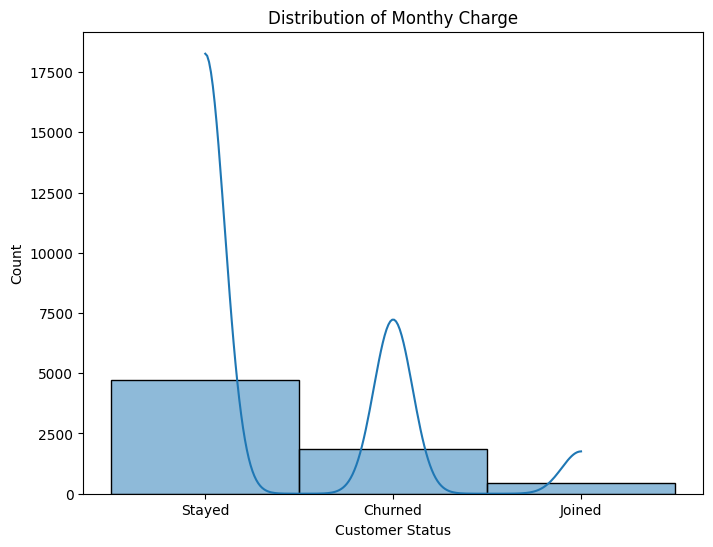

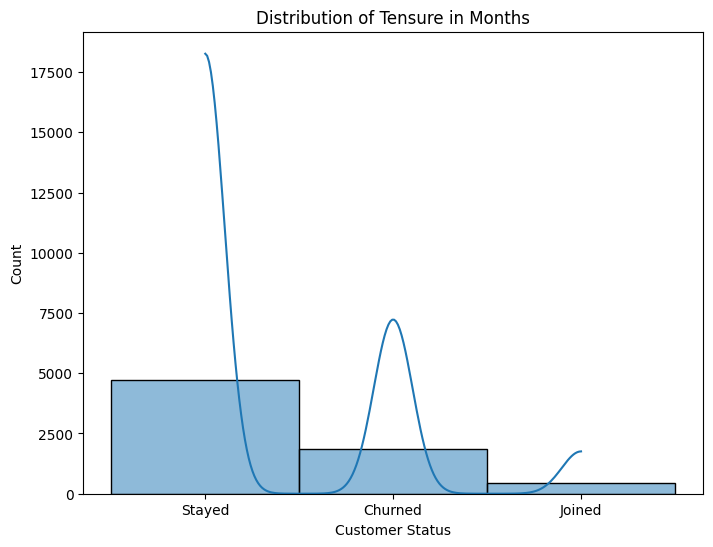

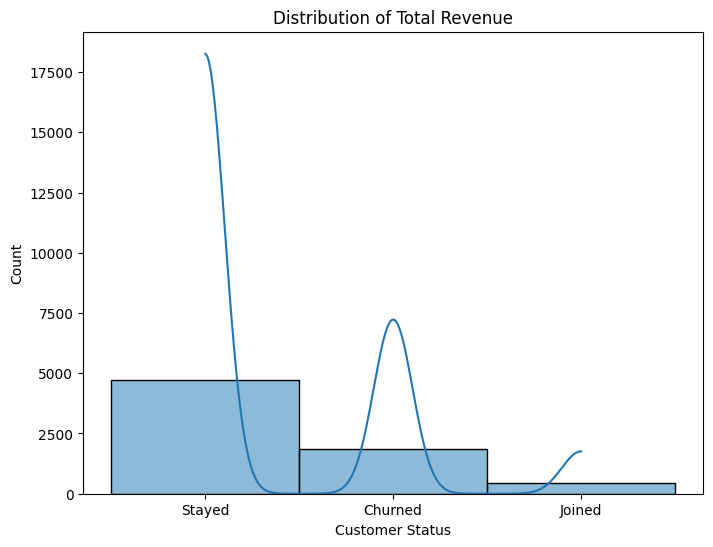

In [13]:
features=['Monthy Charge', 'Tensure in Months', 'Total Revenue']
for feature in features:
    plt.figure(figsize=(8, 6))
    sns.histplot(data=df, x='Customer Status', kde=True)
    plt.title(f'Distribution of {feature}')
    plt.show()

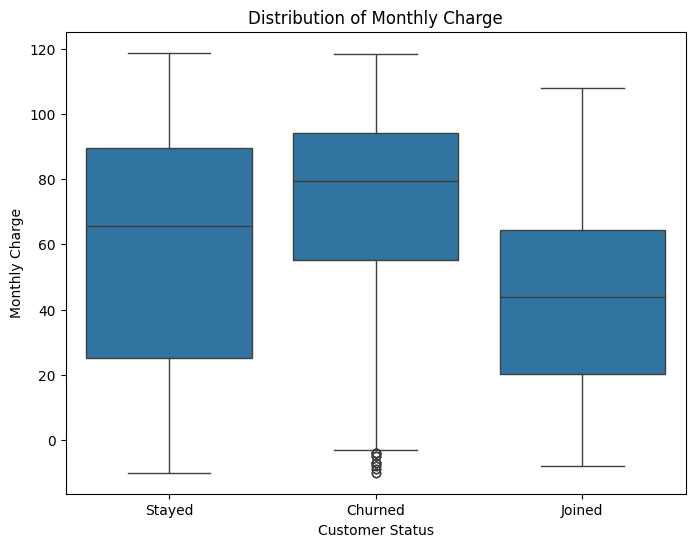

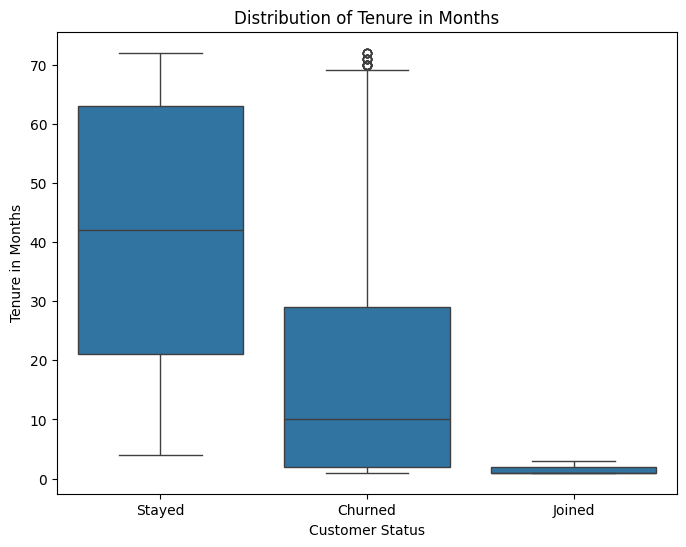

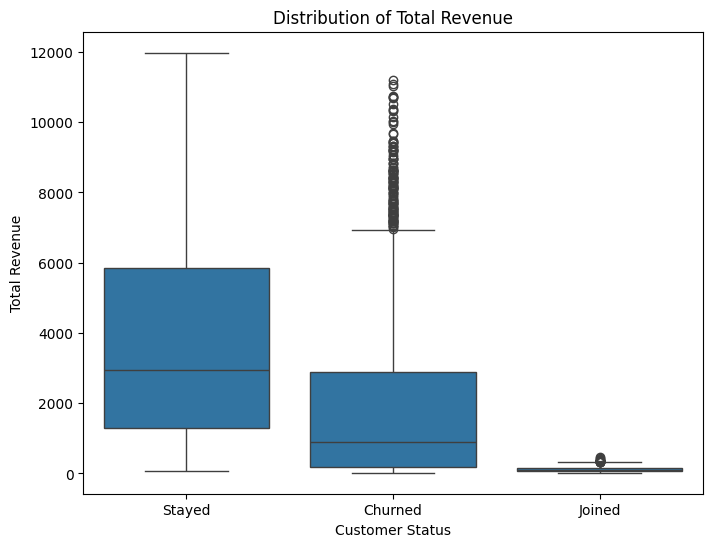

In [14]:
features=['Monthly Charge', 'Tenure in Months', 'Total Revenue']
for feature in features:
    plt.figure(figsize=(8, 6))
    sns.boxplot(x='Customer Status', y=feature, data=df)
    plt.title(f'Distribution of {feature}')
    plt.show()

In [15]:
contract_churn=pd.crosstab(df['Customer Status'], df['Contract'])
print(contract_churn)

Contract         Month-to-Month  One Year  Two Year
Customer Status                                    
Churned                    1655       166        48
Joined                      408        24        22
Stayed                     1547      1360      1813


In [16]:
contract_churn1=pd.crosstab(df['Customer Status'], df['Contract'], normalize='index')*100
print(contract_churn)

Contract         Month-to-Month  One Year  Two Year
Customer Status                                    
Churned                    1655       166        48
Joined                      408        24        22
Stayed                     1547      1360      1813


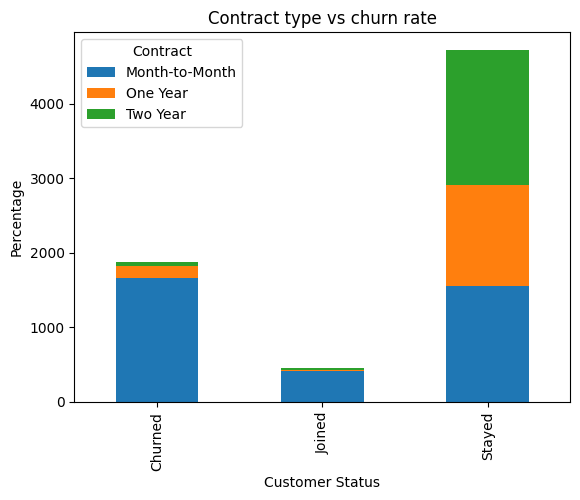

In [17]:
contract_churn.plot(kind='bar', stacked=True)
plt.title("Contract type vs churn rate")
plt.ylabel("Percentage")
plt.show()

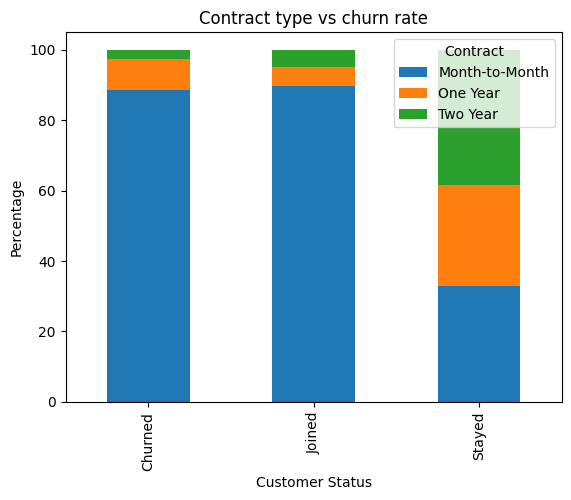

In [18]:
contract_churn1.plot(kind='bar', stacked=True)
plt.title("Contract type vs churn rate")
plt.ylabel("Percentage")
plt.show()

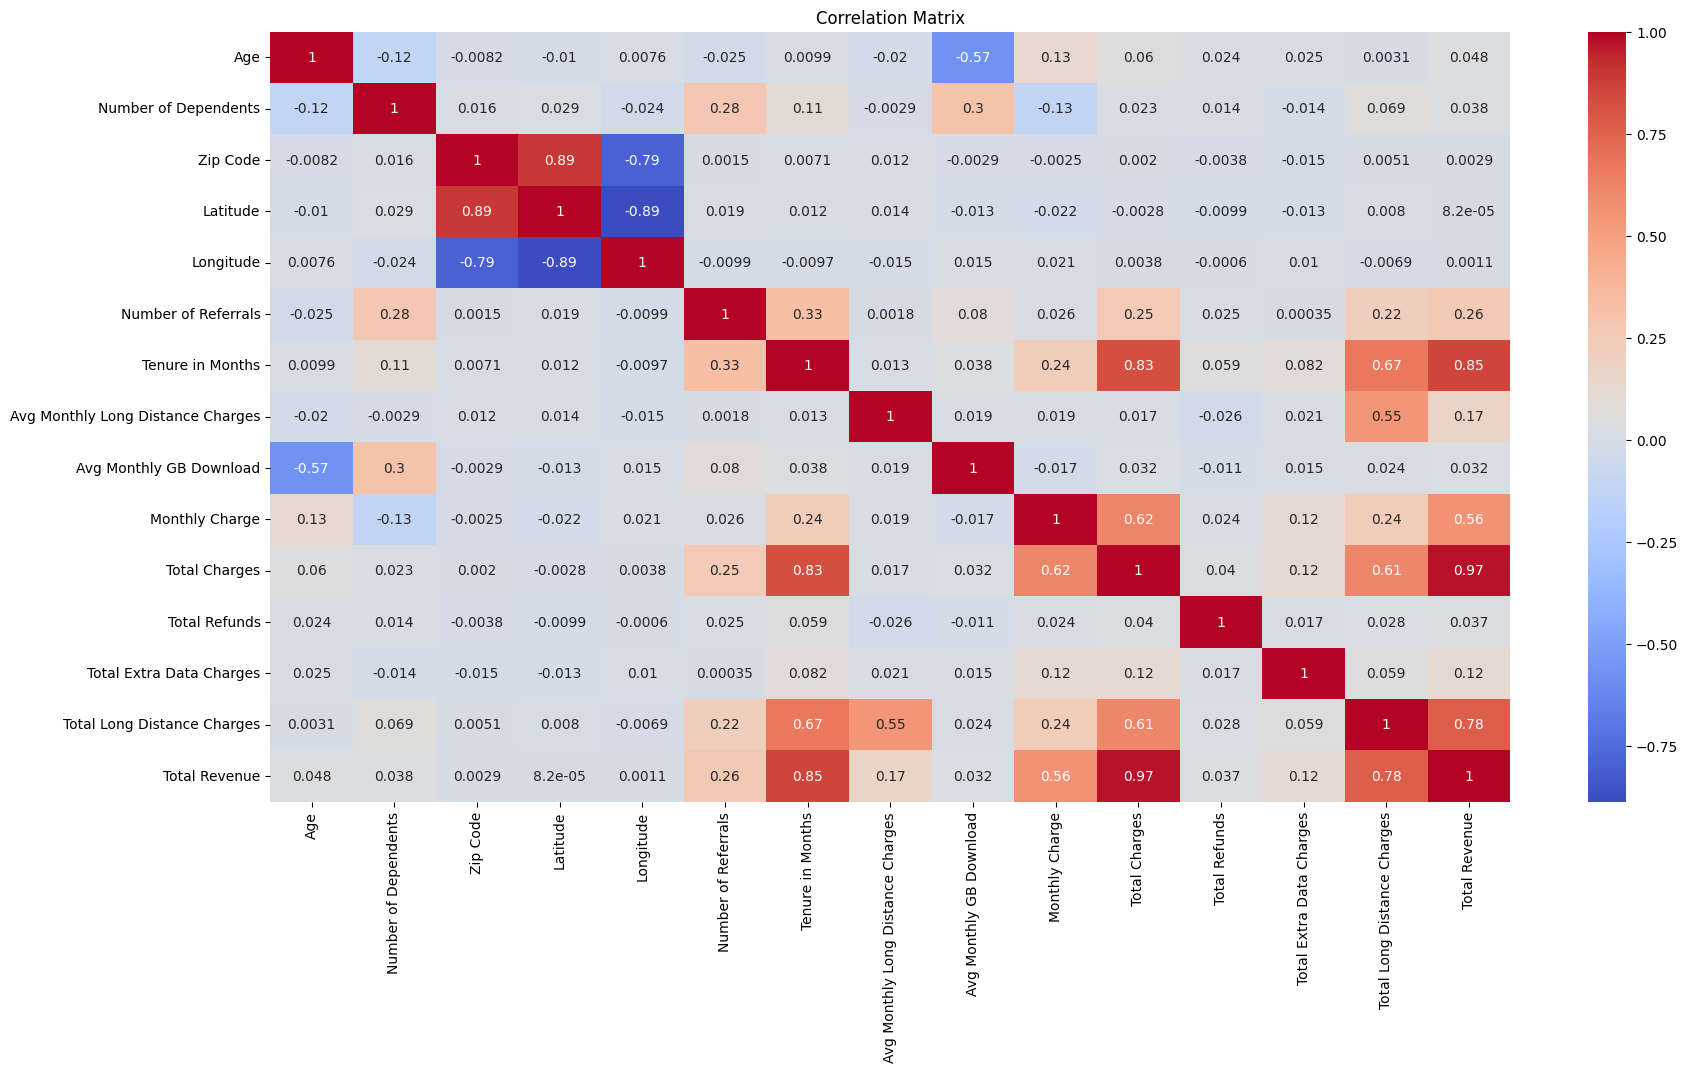

In [19]:
numeric_features=df.select_dtypes(include=['int64', 'float64'])
correlation=numeric_features.corr()
plt.figure(figsize=(20, 10))
sns.heatmap(correlation, annot=True, cmap='coolwarm')
plt.title("Correlation Matrix")
plt.show()

In [20]:
pip install missingno

In [21]:
import missingno as msno

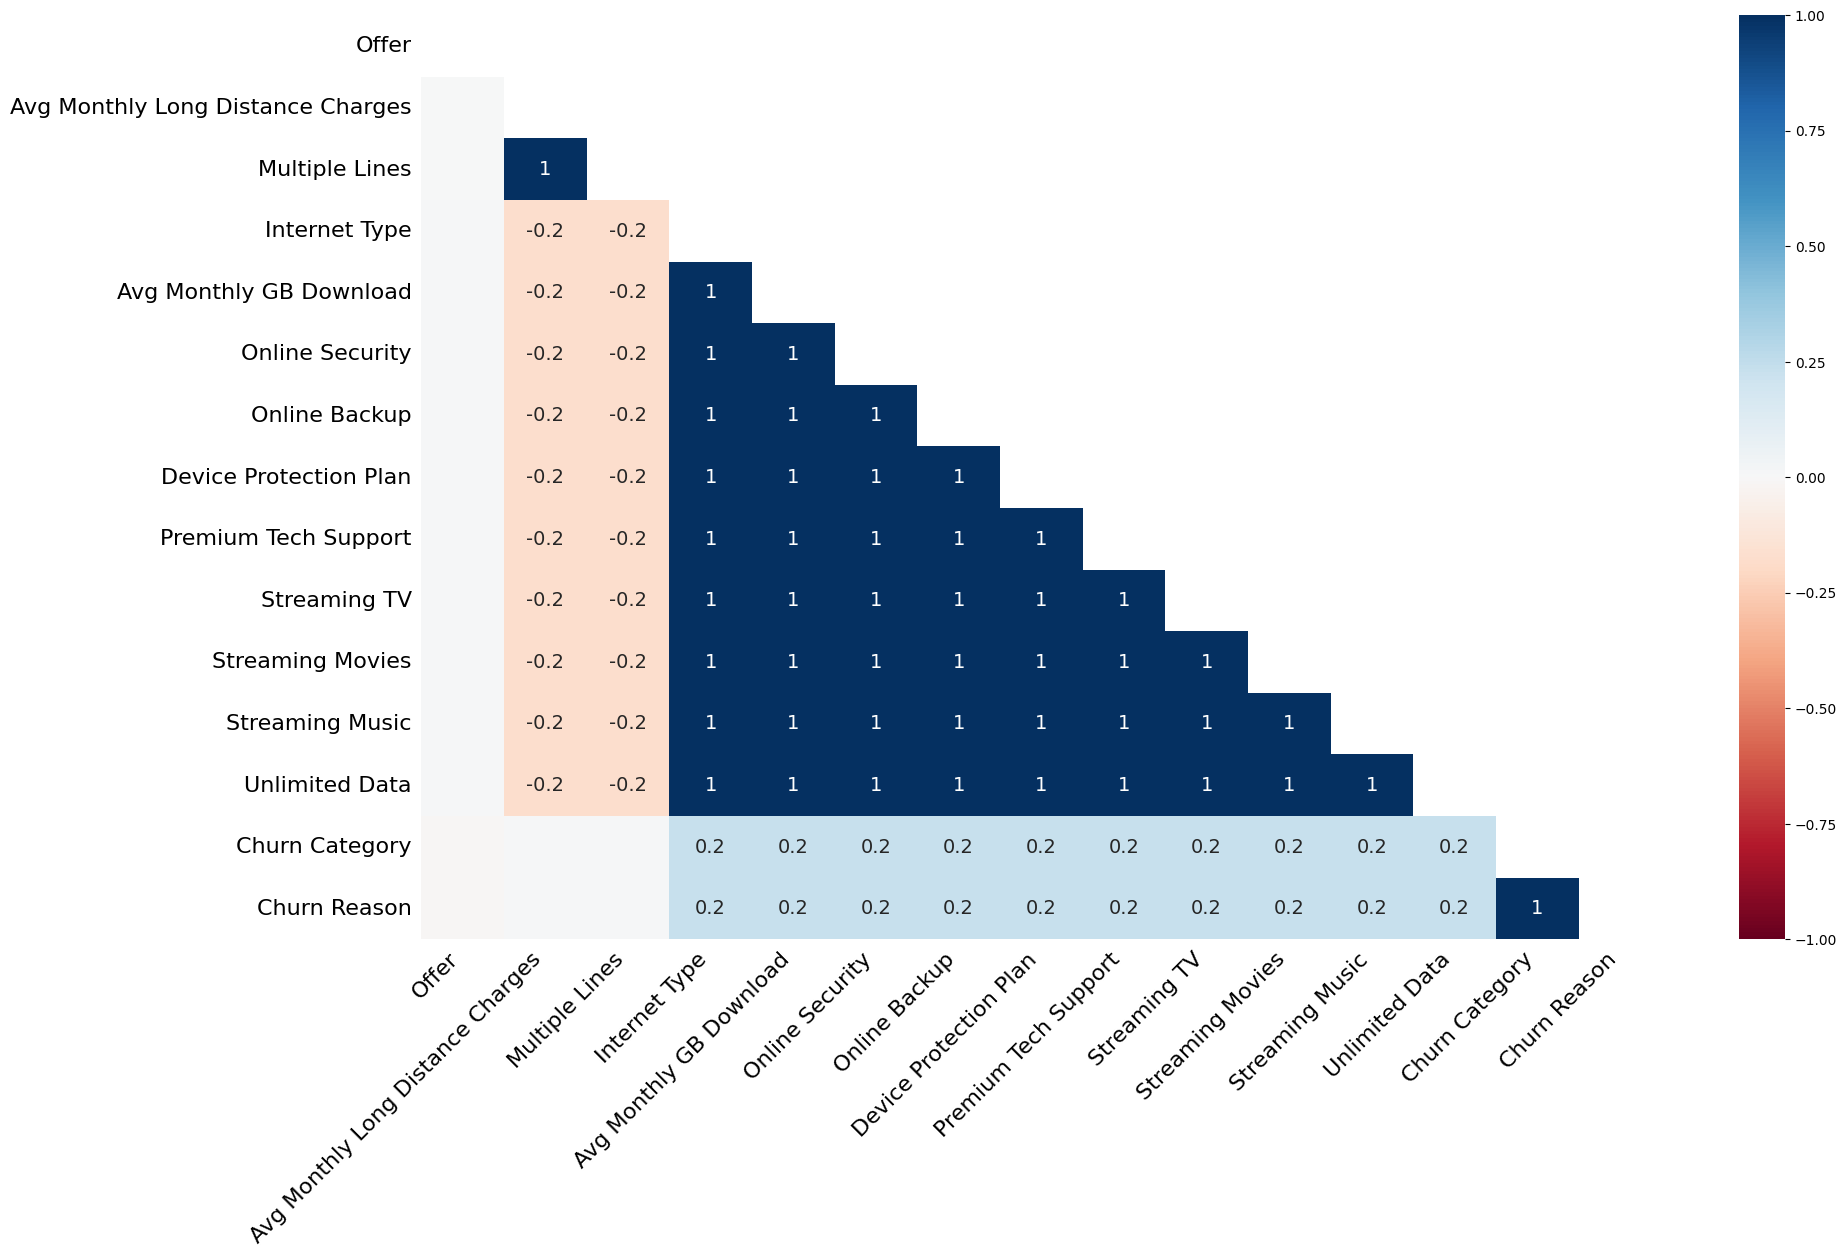

In [22]:
msno.heatmap(df)
plt.show()

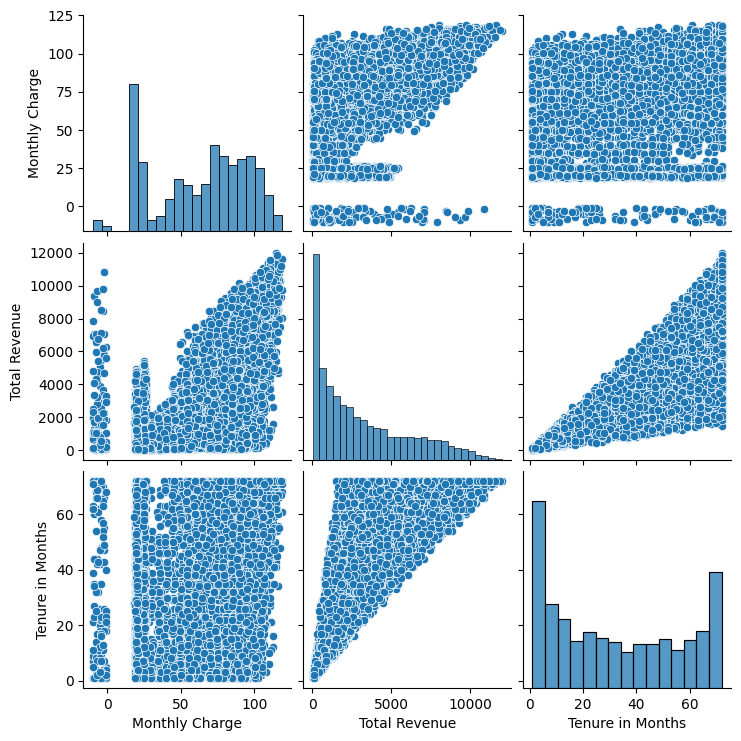

In [23]:
top_corr_features=['Monthly Charge','Total Revenue','Tenure in Months']
sns.pairplot(df[top_corr_features])
plt.show()

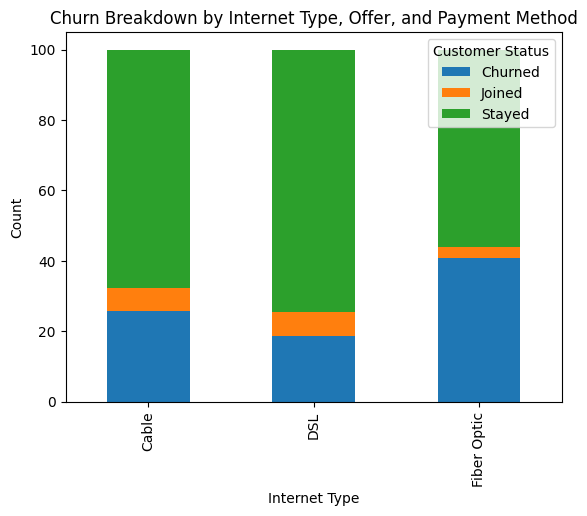

In [24]:
churn_breakdown=pd.crosstab(df['Internet Type'],df['Customer Status'], normalize='index')*100
churn_breakdown.plot(kind='bar', stacked=True)
plt.title("Churn Breakdown by Internet Type, Offer, and Payment Method")
plt.ylabel("Count")
plt.show()

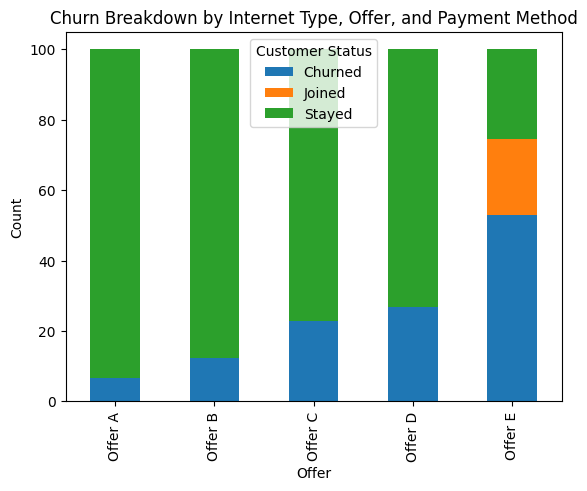

In [25]:
churn_breakdown=pd.crosstab(df['Offer'],df['Customer Status'], normalize='index')*100
churn_breakdown.plot(kind='bar', stacked=True)
plt.title("Churn Breakdown by Internet Type, Offer, and Payment Method")
plt.ylabel("Count")
plt.show()

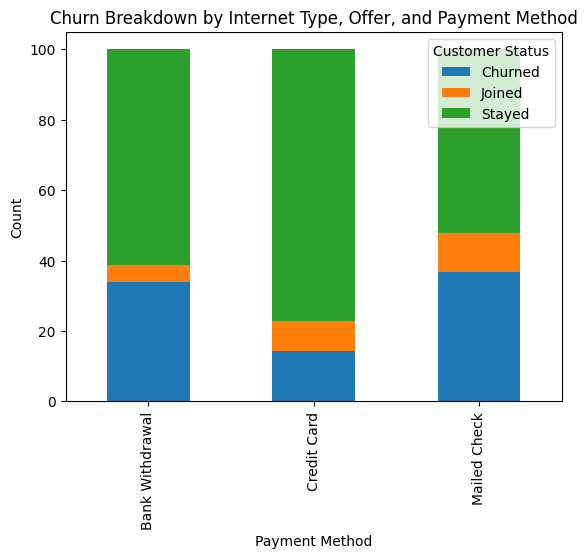

In [26]:
churn_breakdown=pd.crosstab(df['Payment Method'],df['Customer Status'], normalize='index')*100
churn_breakdown.plot(kind='bar', stacked=True)
plt.title("Churn Breakdown by Internet Type, Offer, and Payment Method")
plt.ylabel("Count")
plt.show()

### #3.DATA PREPROCESSING

In [27]:
drop_df=df.drop(columns=['Customer ID','City','Zip Code','Latitude','Longitude'])
drop_df.head()

,Gender,Age,Married,Number of Dependents,Number of Referrals,Tenure in Months,Offer,Phone Service,Avg Monthly Long Distance Charges,Multiple Lines,...,Payment Method,Monthly Charge,Total Charges,Total Refunds,Total Extra Data Charges,Total Long Distance Charges,Total Revenue,Customer Status,Churn Category,Churn Reason
0,Female,37,Yes,0,2,9,NaN,Yes,42.39,No,...,Credit Card,65.6,593.30,0.00,0,381.51,974.81,Stayed,NaN,NaN
1,Male,46,No,0,0,9,NaN,Yes,10.69,Yes,...,Credit Card,-4.0,542.40,38.33,10,96.21,610.28,Stayed,NaN,NaN
2,Male,50,No,0,0,4,Offer E,Yes,33.65,No,...,Bank Withdrawal,73.9,280.85,0.00,0,134.60,415.45,Churned,Competitor,Competitor had better devices
3,Male,78,Yes,0,1,13,Offer D,Yes,27.82,No,...,Bank Withdrawal,98.0,1237.85,0.00,0,361.66,1599.51,Churned,Dissatisfaction,Product dissatisfaction
4,Female,75,Yes,0,3,3,NaN,Yes,7.38,No,...,Credit Card,83.9,267.40,0.00,0,22.14,289.54,Churned,Dissatisfaction,Network reliability


In [28]:
drop1_df=df.drop(columns=['Churn Category','Churn Reason'])
drop1_df.head()

,Customer ID,Gender,Age,Married,Number of Dependents,City,Zip Code,Latitude,Longitude,Number of Referrals,...,Contract,Paperless Billing,Payment Method,Monthly Charge,Total Charges,Total Refunds,Total Extra Data Charges,Total Long Distance Charges,Total Revenue,Customer Status
0,0002-ORFBO,Female,37,Yes,0,Frazier Park,93225,34.827662,-118.999073,2,...,One Year,Yes,Credit Card,65.6,593.30,0.00,0,381.51,974.81,Stayed
1,0003-MKNFE,Male,46,No,0,Glendale,91206,34.162515,-118.203869,0,...,Month-to-Month,No,Credit Card,-4.0,542.40,38.33,10,96.21,610.28,Stayed
2,0004-TLHLJ,Male,50,No,0,Costa Mesa,92627,33.645672,-117.922613,0,...,Month-to-Month,Yes,Bank Withdrawal,73.9,280.85,0.00,0,134.60,415.45,Churned
3,0011-IGKFF,Male,78,Yes,0,Martinez,94553,38.014457,-122.115432,1,...,Month-to-Month,Yes,Bank Withdrawal,98.0,1237.85,0.00,0,361.66,1599.51,Churned
4,0013-EXCHZ,Female,75,Yes,0,Camarillo,93010,34.227846,-119.079903,3,...,Month-to-Month,Yes,Credit Card,83.9,267.40,0.00,0,22.14,289.54,Churned


In [29]:
df['Binary'] = df['Customer Status'].map({'Churned': 1, 'Stayed': 0, 'Joined':0})
df['Binary'].head(24)

,Binary
0,0
1,0
2,1
3,1
4,1
5,0
6,0
7,0
8,0
9,0


In [30]:
categorical_col=df.select_dtypes(include=['object','category']).columns
df[categorical_col]=df[categorical_col].fillna('Unknown')
df[categorical_col].head()

,Customer ID,Gender,Married,City,Offer,Phone Service,Multiple Lines,Internet Service,Internet Type,Online Security,...,Streaming TV,Streaming Movies,Streaming Music,Unlimited Data,Contract,Paperless Billing,Payment Method,Customer Status,Churn Category,Churn Reason
0,0002-ORFBO,Female,Yes,Frazier Park,Unknown,Yes,No,Yes,Cable,No,...,Yes,No,No,Yes,One Year,Yes,Credit Card,Stayed,Unknown,Unknown
1,0003-MKNFE,Male,No,Glendale,Unknown,Yes,Yes,Yes,Cable,No,...,No,Yes,Yes,No,Month-to-Month,No,Credit Card,Stayed,Unknown,Unknown
2,0004-TLHLJ,Male,No,Costa Mesa,Offer E,Yes,No,Yes,Fiber Optic,No,...,No,No,No,Yes,Month-to-Month,Yes,Bank Withdrawal,Churned,Competitor,Competitor had better devices
3,0011-IGKFF,Male,Yes,Martinez,Offer D,Yes,No,Yes,Fiber Optic,No,...,Yes,Yes,No,Yes,Month-to-Month,Yes,Bank Withdrawal,Churned,Dissatisfaction,Product dissatisfaction
4,0013-EXCHZ,Female,Yes,Camarillo,Unknown,Yes,No,Yes,Fiber Optic,No,...,Yes,No,No,Yes,Month-to-Month,Yes,Credit Card,Churned,Dissatisfaction,Network reliability


In [31]:
numerical_col=df.select_dtypes(include=['number']).columns
for col in numerical_col:
    df[col]=df[col].fillna(df[col].median())
df[col].head()

,Binary
0,0
1,0
2,1
3,1
4,1


In [32]:
df['Offer']=df['Offer'].replace('Unknown','No Offer')
df['Offer'].head()

,Offer
0,No Offer
1,No Offer
2,Offer E
3,Offer D
4,No Offer


In [33]:
from sklearn.preprocessing import LabelEncoder
cate_cols=df.select_dtypes(include=['object']).columns
df[cate_cols]=df[cate_cols].apply(LabelEncoder().fit_transform)

In [34]:
cat_cols=df.select_dtypes(include=['object']).columns
encoders={}
for cols in cat_cols:
  le=LabelEncoder()
  df[cols]=le.fit_transform(df[cols])
  encoders[cols]=le

In [35]:
df['Avg_rev_per_month']=df['Total Revenue']/df['Tenure in Months']+1

In [36]:
df['Charge_to_Tenure_Ratio']=df['Monthly Charge']/df['Tenure in Months']+1

In [37]:
df[['Avg_rev_per_month','Charge_to_Tenure_Ratio']].head()


,Avg_rev_per_month,Charge_to_Tenure_Ratio
0,109.312222,8.288889
1,68.808889,0.555556
2,104.862500,19.475000
3,124.039231,8.538462
4,97.513333,28.966667


### #4.MODEL TRAINING

In [38]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# =========================
# Remove leakage columns
# =========================

X = df.drop([
    'Customer ID',
    'Binary',
    'Customer Status',
    'Churn Category',
    'Churn Reason'
], axis=1)

y = df['Binary']

# =========================
# One-hot encoding
# =========================

X = pd.get_dummies(X, drop_first=True)

# =========================
# Train-test split
# =========================

X_train, X_val, y_train, y_val = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# =========================
# Scaling
# =========================

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)

# =========================
# Logistic Regression
# =========================

lr = LogisticRegression(
    max_iter=5000,
    class_weight='balanced',
    random_state=42
)

lr.fit(X_train_scaled, y_train)

# =========================
# Prediction
# =========================

y_pred_lr= lr.predict(X_val_scaled)

# =========================
# Evaluation
# =========================

print("Accuracy:",
      accuracy_score(y_val, y_pred_lr))

print("\nClassification Report:\n")
print(classification_report(y_val, y_pred_lr))

print("\nConfusion Matrix:\n")
print(confusion_matrix(y_val, y_pred_lr))

Accuracy: 0.7821149751596878

Classification Report:

              precision    recall  f1-score   support

           0       0.93      0.76      0.84      1035
           1       0.56      0.85      0.67       374

    accuracy                           0.78      1409
   macro avg       0.75      0.80      0.76      1409
weighted avg       0.83      0.78      0.79      1409


Confusion Matrix:

[[784 251]
 [ 56 318]]


In [39]:
print(X.columns.tolist())

['Gender', 'Age', 'Married', 'Number of Dependents', 'City', 'Zip Code', 'Latitude', 'Longitude', 'Number of Referrals', 'Tenure in Months', 'Offer', 'Phone Service', 'Avg Monthly Long Distance Charges', 'Multiple Lines', 'Internet Service', 'Internet Type', 'Avg Monthly GB Download', 'Online Security', 'Online Backup', 'Device Protection Plan', 'Premium Tech Support', 'Streaming TV', 'Streaming Movies', 'Streaming Music', 'Unlimited Data', 'Contract', 'Paperless Billing', 'Payment Method', 'Monthly Charge', 'Total Charges', 'Total Refunds', 'Total Extra Data Charges', 'Total Long Distance Charges', 'Total Revenue', 'Avg_rev_per_month', 'Charge_to_Tenure_Ratio']


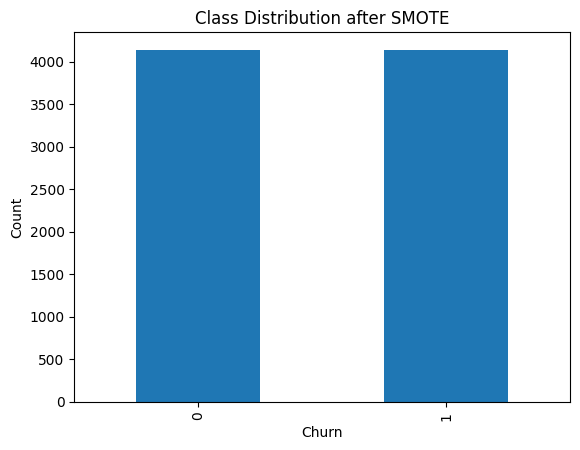

In [40]:
from imblearn.over_sampling import SMOTE
sm=SMOTE(random_state=42)
X_train_sm, y_train_sm=sm.fit_resample(X_train_scaled,y_train)
y_train_sm.value_counts().plot(kind='bar')
plt.title("Class Distribution after SMOTE")
plt.xlabel('Churn')
plt.ylabel('Count')
plt.show()

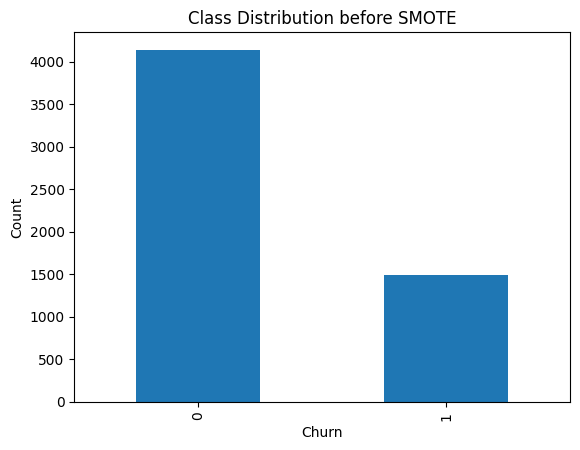

In [41]:
y_train.value_counts().plot(kind='bar')
plt.title("Class Distribution before SMOTE")
plt.xlabel('Churn')
plt.ylabel('Count')
plt.show()

In [42]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_val)

print("Accuracy:", accuracy_score(y_val, y_pred_rf))

print("\nClassification Report:\n")
print(classification_report(y_val, y_pred_rf))

print("\nConfusion Matrix:\n")
print(confusion_matrix(y_val, y_pred_rf))

Accuracy: 0.830376153300213

Classification Report:

              precision    recall  f1-score   support

           0       0.87      0.91      0.89      1035
           1       0.71      0.61      0.66       374

    accuracy                           0.83      1409
   macro avg       0.79      0.76      0.77      1409
weighted avg       0.82      0.83      0.83      1409


Confusion Matrix:

[[943  92]
 [147 227]]


In [43]:
from sklearn.tree import DecisionTreeClassifier

dt = DecisionTreeClassifier(
    max_depth=5,
    random_state=42
)

dt.fit(X_train, y_train)

y_pred_dt = dt.predict(X_val)

print("Accuracy:", accuracy_score(y_val, y_pred_dt))

print("\nClassification Report:\n")
print(classification_report(y_val, y_pred_dt))

print("\nConfusion Matrix:\n")
print(confusion_matrix(y_val, y_pred_dt))

Accuracy: 0.8105039034776437

Classification Report:

              precision    recall  f1-score   support

           0       0.84      0.92      0.88      1035
           1       0.69      0.52      0.59       374

    accuracy                           0.81      1409
   macro avg       0.77      0.72      0.73      1409
weighted avg       0.80      0.81      0.80      1409


Confusion Matrix:

[[949  86]
 [181 193]]


In [44]:
from sklearn.ensemble import AdaBoostClassifier

ada = AdaBoostClassifier(
    n_estimators=100,
    random_state=42
)

ada.fit(X_train, y_train)

y_pred_ada = ada.predict(X_val)

print("Accuracy:", accuracy_score(y_val, y_pred_ada))

print("\nClassification Report:\n")
print(classification_report(y_val, y_pred_ada))

print("\nConfusion Matrix:\n")
print(confusion_matrix(y_val, y_pred_ada))


Accuracy: 0.8332150461320085

Classification Report:

              precision    recall  f1-score   support

           0       0.88      0.89      0.89      1035
           1       0.69      0.67      0.68       374

    accuracy                           0.83      1409
   macro avg       0.79      0.78      0.78      1409
weighted avg       0.83      0.83      0.83      1409


Confusion Matrix:

[[923 112]
 [123 251]]


In [45]:
from xgboost import XGBClassifier

xgb = XGBClassifier(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=5,
    random_state=42
)

xgb.fit(X_train, y_train)

y_pred_xgb = xgb.predict(X_val)

print("Accuracy:", accuracy_score(y_val, y_pred_xgb))

print("\nClassification Report:\n")
print(classification_report(y_val, y_pred_xgb))

print("\nConfusion Matrix:\n")
print(confusion_matrix(y_val, y_pred_xgb))

Accuracy: 0.8516678495386799

Classification Report:

              precision    recall  f1-score   support

           0       0.89      0.91      0.90      1035
           1       0.74      0.69      0.71       374

    accuracy                           0.85      1409
   macro avg       0.81      0.80      0.81      1409
weighted avg       0.85      0.85      0.85      1409


Confusion Matrix:

[[943  92]
 [117 257]]


In [46]:
from sklearn.naive_bayes import GaussianNB

nb = GaussianNB()

nb.fit(X_train_scaled, y_train)

y_pred_nb = nb.predict(X_val_scaled)

print("Accuracy:", accuracy_score(y_val, y_pred_nb))

print("\nClassification Report:\n")
print(classification_report(y_val, y_pred_nb))

print("\nConfusion Matrix:\n")
print(confusion_matrix(y_val, y_pred_nb))

Accuracy: 0.7764371894960965

Classification Report:

              precision    recall  f1-score   support

           0       0.89      0.79      0.84      1035
           1       0.56      0.74      0.64       374

    accuracy                           0.78      1409
   macro avg       0.73      0.76      0.74      1409
weighted avg       0.80      0.78      0.78      1409


Confusion Matrix:

[[818 217]
 [ 98 276]]


In [47]:
from sklearn.neighbors import KNeighborsClassifier

knn = KNeighborsClassifier(
    n_neighbors=5
)

knn.fit(X_train_scaled, y_train)

y_pred_knn = knn.predict(X_val_scaled)

print("Accuracy:", accuracy_score(y_val, y_pred_knn))

print("\nClassification Report:\n")
print(classification_report(y_val, y_pred_knn))

print("\nConfusion Matrix:\n")
print(confusion_matrix(y_val, y_pred_knn))

Accuracy: 0.801277501774308

Classification Report:

              precision    recall  f1-score   support

           0       0.84      0.90      0.87      1035
           1       0.65      0.54      0.59       374

    accuracy                           0.80      1409
   macro avg       0.75      0.72      0.73      1409
weighted avg       0.79      0.80      0.79      1409


Confusion Matrix:

[[927 108]
 [172 202]]


In [48]:
from sklearn.ensemble import GradientBoostingClassifier

gb = GradientBoostingClassifier(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=3,
    random_state=42
)

gb.fit(X_train, y_train)

y_pred_gb = gb.predict(X_val)

print("Accuracy:", accuracy_score(y_val, y_pred_gb))

print("\nClassification Report:\n")
print(classification_report(y_val, y_pred_gb))

print("\nConfusion Matrix:\n")
print(confusion_matrix(y_val, y_pred_gb))

Accuracy: 0.850958126330731

Classification Report:

              precision    recall  f1-score   support

           0       0.88      0.92      0.90      1035
           1       0.75      0.67      0.70       374

    accuracy                           0.85      1409
   macro avg       0.81      0.79      0.80      1409
weighted avg       0.85      0.85      0.85      1409


Confusion Matrix:

[[950  85]
 [125 249]]


In [49]:
from sklearn.svm import SVC
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)
svc = SVC(
    kernel='rbf',
    class_weight='balanced',
    random_state=42
)
svc.fit(X_train_scaled, y_train)
y_pred_svc = svc.predict(X_val_scaled)
print("Accuracy:",
      accuracy_score(y_val, y_pred_svc))

print("\nClassification Report:\n")
print(classification_report(y_val, y_pred_svc))

print("\nConfusion Matrix:\n")
print(confusion_matrix(y_val, y_pred_svc))

Accuracy: 0.794889992902768

Classification Report:

              precision    recall  f1-score   support

           0       0.93      0.78      0.85      1035
           1       0.58      0.84      0.69       374

    accuracy                           0.79      1409
   macro avg       0.76      0.81      0.77      1409
weighted avg       0.84      0.79      0.80      1409


Confusion Matrix:

[[804 231]
 [ 58 316]]


In [50]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

In [51]:
comparison = pd.DataFrame({

    'Model': [
        'Logistic Regression','Random Forest','Decision Tree','AdaBoost','XGBoost','Gradient Boosting',
      'KNN','SVC','Naive Bayes'
    ],

    'Accuracy': [
        accuracy_score(y_val, y_pred_lr),
        accuracy_score(y_val, y_pred_rf),
        accuracy_score(y_val, y_pred_dt),
        accuracy_score(y_val, y_pred_ada),
        accuracy_score(y_val, y_pred_xgb),
        accuracy_score(y_val, y_pred_gb),
        accuracy_score(y_val, y_pred_knn),
        accuracy_score(y_val, y_pred_svc),
        accuracy_score(y_val, y_pred_nb),
    ],

    'Precision': [
        precision_score(y_val, y_pred_lr),
        precision_score(y_val, y_pred_rf),
        precision_score(y_val, y_pred_dt),
        precision_score(y_val, y_pred_ada),
        precision_score(y_val, y_pred_xgb),
        precision_score(y_val, y_pred_gb),
        precision_score(y_val, y_pred_knn),
        precision_score(y_val, y_pred_svc),
        precision_score(y_val, y_pred_nb)
    ],

    'Recall': [
        recall_score(y_val, y_pred_lr),
        recall_score(y_val, y_pred_rf),
        recall_score(y_val, y_pred_dt),
        recall_score(y_val, y_pred_ada),
        recall_score(y_val, y_pred_xgb),
        recall_score(y_val, y_pred_gb),
        recall_score(y_val, y_pred_knn),
        recall_score(y_val, y_pred_svc),
        recall_score(y_val, y_pred_nb)
    ],

    'F1 Score': [
        f1_score(y_val, y_pred_lr),
        f1_score(y_val, y_pred_rf),
        f1_score(y_val, y_pred_dt),
        f1_score(y_val, y_pred_ada),
        f1_score(y_val, y_pred_xgb),
        f1_score(y_val, y_pred_gb),
        f1_score(y_val, y_pred_knn),
        f1_score(y_val, y_pred_svc),
        f1_score(y_val, y_pred_nb)
    ]
})

In [52]:
comparison = comparison.sort_values(
    by='Accuracy',
    ascending=False
)

print(comparison)

                 Model  Accuracy  Precision    Recall  F1 Score
4              XGBoost  0.851668   0.736390  0.687166  0.710927
5    Gradient Boosting  0.850958   0.745509  0.665775  0.703390
3             AdaBoost  0.833215   0.691460  0.671123  0.681140
1        Random Forest  0.830376   0.711599  0.606952  0.655123
2        Decision Tree  0.810504   0.691756  0.516043  0.591118
6                  KNN  0.801278   0.651613  0.540107  0.590643
7                  SVC  0.794890   0.577697  0.844920  0.686211
0  Logistic Regression  0.782115   0.558875  0.850267  0.674443
8          Naive Bayes  0.776437   0.559838  0.737968  0.636678


In [53]:
comparison = comparison.sort_values(
    by='F1 Score',
    ascending=False
)

print(comparison)

                 Model  Accuracy  Precision    Recall  F1 Score
4              XGBoost  0.851668   0.736390  0.687166  0.710927
5    Gradient Boosting  0.850958   0.745509  0.665775  0.703390
7                  SVC  0.794890   0.577697  0.844920  0.686211
3             AdaBoost  0.833215   0.691460  0.671123  0.681140
0  Logistic Regression  0.782115   0.558875  0.850267  0.674443
1        Random Forest  0.830376   0.711599  0.606952  0.655123
8          Naive Bayes  0.776437   0.559838  0.737968  0.636678
2        Decision Tree  0.810504   0.691756  0.516043  0.591118
6                  KNN  0.801278   0.651613  0.540107  0.590643


In [54]:
from sklearn.model_selection import StratifiedKFold
from sklearn.model_selection import cross_val_score

models = {
    "Gradient Boosting": GradientBoostingClassifier(
        random_state=42
    ),
    "SVM": SVC(
        random_state=42
    ),

    "XGBoost": XGBClassifier(
        random_state=42
    )
}
skf = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

for name, model in models.items():

    scores = cross_val_score(
        model,
        X_train_sm,
        y_train_sm,
        cv=skf,
        scoring='f1'
    )

    print(f"\n{name}")

    print("F1 Scores:", scores)

    print("Mean F1:", np.mean(scores))

    print("Std Dev:", np.std(scores))



Gradient Boosting
F1 Scores: [0.88147707 0.88648649 0.88071217 0.89296274 0.88953828]
Mean F1: 0.8862353495976064
Std Dev: 0.004677115516131975

SVM
F1 Scores: [0.85911443 0.87182448 0.86392588 0.87212728 0.86996548]
Mean F1: 0.8673915115975956
Std Dev: 0.0050837909019582645

XGBoost
F1 Scores: [0.89546828 0.89268293 0.89498807 0.9005425  0.90563798]
Mean F1: 0.8978639498551427
Std Dev: 0.00465753437315918


In [55]:
best_model = XGBClassifier(random_state=42)

best_model.fit(X_train, y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=None, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=None,
              n_jobs=None, num_parallel_tree=None, ...)

In [56]:
y_test_pred = best_model.predict(X_val)

y_test_prob = best_model.predict_proba(X_val)[:,1]

In [57]:
print(classification_report(y_val, y_test_pred))
print(confusion_matrix(y_val, y_test_pred))

              precision    recall  f1-score   support

           0       0.88      0.89      0.89      1035
           1       0.70      0.67      0.68       374

    accuracy                           0.84      1409
   macro avg       0.79      0.78      0.79      1409
weighted avg       0.83      0.84      0.83      1409

[[926 109]
 [123 251]]


In [58]:
from sklearn.metrics import roc_curve, roc_auc_score

In [59]:
auc_score=roc_auc_score(y_val,y_test_prob)
print("AUC Score:",auc_score)


AUC Score: 0.9022862900100751


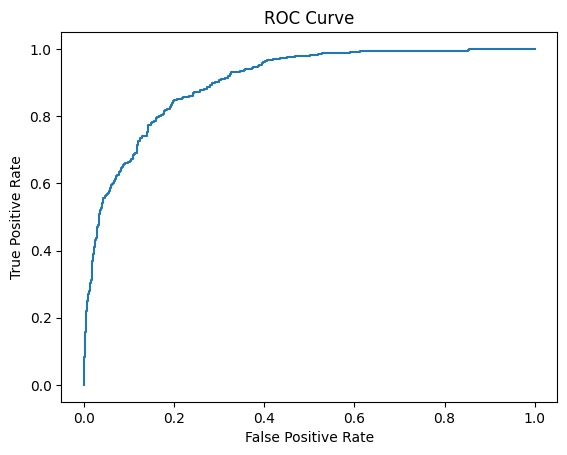

In [60]:
fpr, tpr, thresholds = roc_curve(
    y_val,
    y_test_prob
)

plt.plot(fpr, tpr)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")

plt.title("ROC Curve")

plt.show()

In [61]:
feature_importance = pd.DataFrame({

    'Feature': X_train.columns,

    'Importance': best_model.feature_importances_

})

In [62]:
feature_importance = feature_importance.sort_values(
    by='Importance',
    ascending=False
)

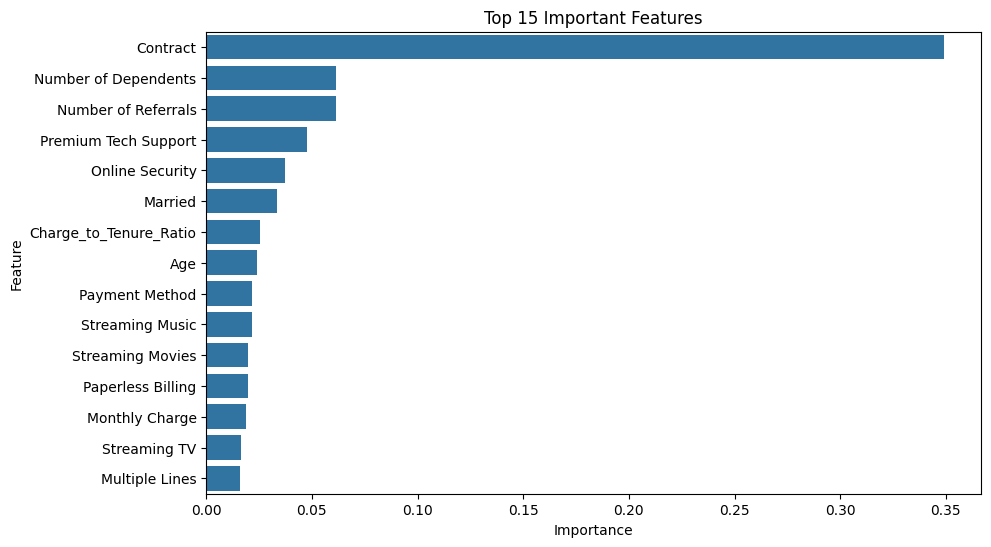

In [63]:
top_features = feature_importance.head(15)

plt.figure(figsize=(10,6))

sns.barplot(
    x='Importance',
    y='Feature',
    data=top_features
)

plt.title("Top 15 Important Features")

plt.show()

In [69]:
from sklearn.inspection import permutation_importance
perm_importance = permutation_importance(
    best_model,
    X_val,
    y_val,
    n_repeats=10,
    random_state=42
)

In [70]:
import joblib

joblib.dump(
    best_model,
    'best_churn_model.pkl'
)

['best_churn_model.pkl']

In [71]:
joblib.dump(
    scaler,
    'scaler.pkl'
)

['scaler.pkl']

In [75]:
joblib.dump(
    LabelEncoder,
    'label_encoders.pkl'
)

['label_encoders.pkl']

In [77]:
comparison.to_csv(
    'model_comparison_results.csv',
    index=False
)

In [78]:
def predict_churn(new_data):

    # Convert to DataFrame
    new_df = pd.DataFrame([new_data])

    # Feature Engineering
    new_df['Avg_Revenue_per_Month'] = (
        new_df['Total Revenue'] /
        (new_df['Tenure in Months'] + 1)
    )

    new_df['Charge_to_Tenure_Ratio'] = (
        new_df['Monthly Charge'] /
        (new_df['Tenure in Months'] + 1)
    )

    # Encode categorical columns
    for col in categorical_cols:

        if col in label_encoders:

            new_df[col] = label_encoders[col].transform(
                new_df[col]
            )

    # Scale
    new_scaled = scaler.transform(new_df)

    # Predict probability
    churn_prob = best_model.predict_proba(
        new_scaled
    )[:,1]

    # Binary prediction
    prediction = best_model.predict(
        new_scaled
    )

    return {

        "Churn Probability": churn_prob[0],

        "Prediction": prediction[0]
    }